## This file describes the step of combining HES with NPD to create ECHILD data

In [2]:
# !pip install scipy
# !pip install statsmodels

     --------------------------------------- 46.2/46.2 MB 26.2 MB/s eta 0:00:00

[notice] A new release of pip available: 22.1.2 -> 23.3.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from statsmodels.graphics.gofplots import qqplot
from scipy.stats import shapiro

In [2]:
# Load the data
spine = pd.read_csv("2_spine_jupyter.csv")
npd = pd.read_csv("3_KS1_jupyter.csv")
hes = pd.read_csv("4_HES_jupyter.csv")

# Merge data
combine = pd.merge(npd, spine, on="PupilMatchingRefAnonymous", how="left")
combine = pd.merge(combine, hes, on="tokenid", how="left")
combine['any_comorbidity'] = np.where(combine['diag_02'].notna(), "Yes", "No")

# Tabulate gender in NPD and Sex in HES
pd.crosstab(combine['KS1_GENDER'], combine['sex'])



sex,1,2
KS1_GENDER,,
F,0,250308
M,249692,0


In [3]:
# Function to generate aggregate results
def generate_aggregate_results(column_name, levs):
    out = pd.DataFrame()
    for val in combine[column_name].unique():
        temp = combine[combine[column_name] == val]
        out = pd.concat([out, pd.DataFrame({
            column_name: [val],
            'median': [temp['KS1_MATH'].median()],
            'lower': [temp['KS1_MATH'].quantile(0.25)],
            'upper': [temp['KS1_MATH'].quantile(0.75)],
        })])
    
    out[column_name] = pd.Categorical(out[column_name], categories=levs, ordered=True)
    out = out.sort_values(by=column_name)
    out.reset_index(drop=True, inplace=True)
    return out

# Generate aggregate results
gestat_and_ks1 = generate_aggregate_results("gestat", ["less_than_28", "28_29", "30_31", "32", "33", "34", "35", "36", "37", "38", "39", "40", "41", "42"])
imd_and_ks1 = generate_aggregate_results("imd04_decile", ["Least Deprived 10%", "Less Deprived 10% - 20%", "Less Deprived 20% - 30%", "Less Deprived 30% - 40%", "Less Deprived 40% - 50%", "More Deprived 40% - 50%", "More Deprived 30% - 40%", "More Deprived 20% - 30%", "More Deprived 10% - 20%", "Most Deprived 10%"])
gender_and_ks1 = generate_aggregate_results("KS1_GENDER", ["M", "F"])
month_and_ks1 = generate_aggregate_results("KS1_MONTH_PART", [0, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1])
comorbidity_and_ks1 = generate_aggregate_results("any_comorbidity", ["No", "Yes"])

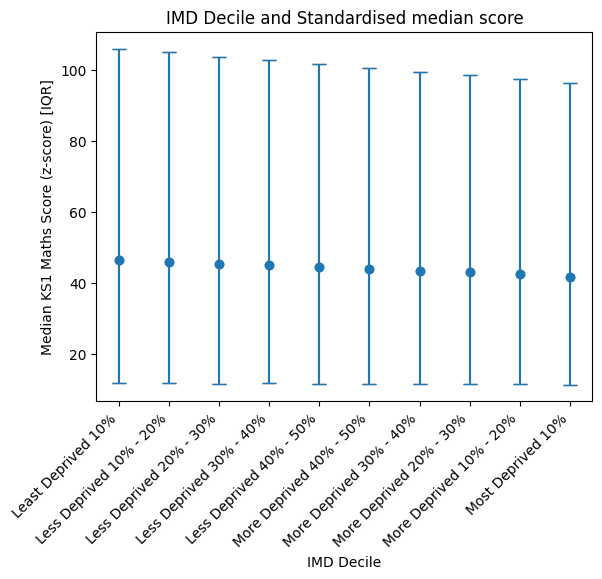

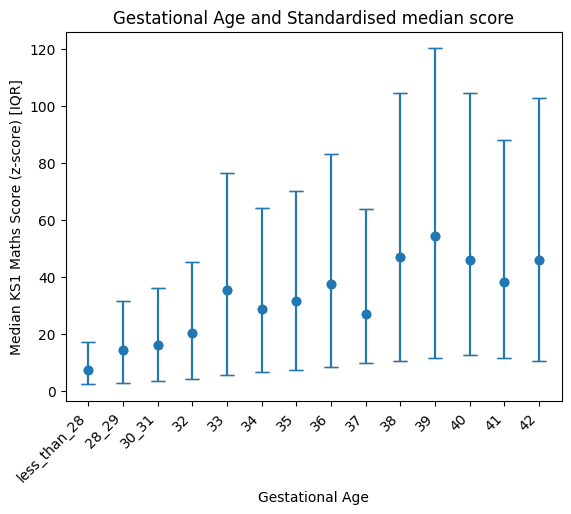

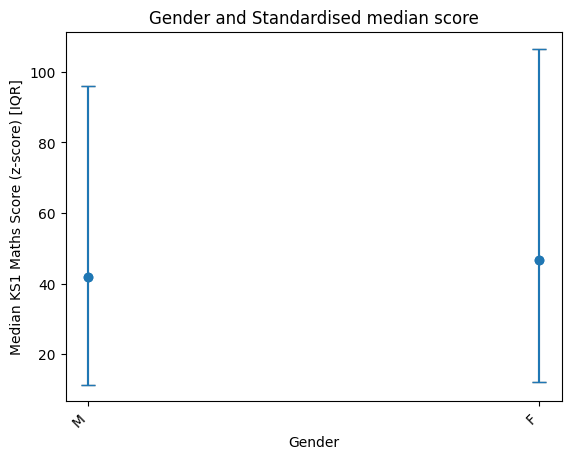

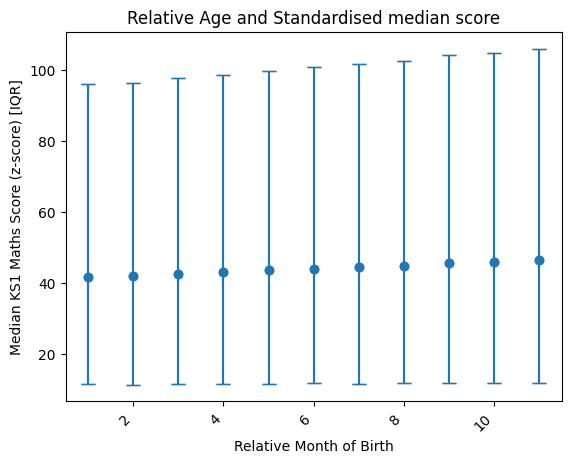

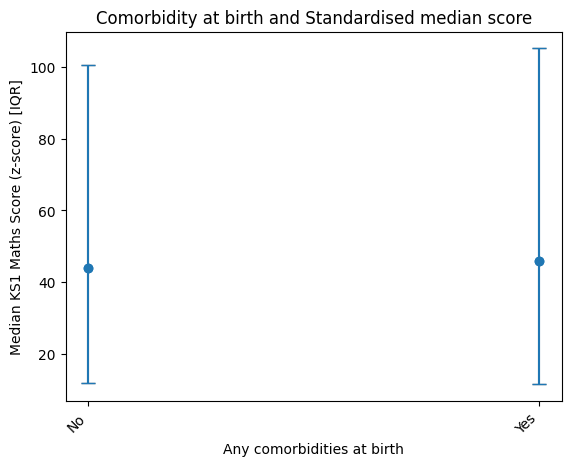

In [4]:
# Function to plot data
def plotit(x_values, y_values, lower_ci, upper_ci, xLab, yLab, Main):
    fig, ax = plt.subplots()
    ax.plot(x_values, y_values, 'o')
    ax.errorbar(x_values, y_values, yerr=[lower_ci, upper_ci], fmt='none', ecolor='gray', capsize=5)
    
    plt.scatter(x_values, y_values)
    plt.errorbar(x_values, y_values, yerr=(lower_ci, upper_ci), fmt='none', capsize=5)
    plt.xlabel(xLab)
    plt.ylabel(yLab)
    plt.title(Main)

    plt.xticks(rotation = 45, ha='right')
   
    plt.show()

# Plotting
plotit(imd_and_ks1['imd04_decile'], imd_and_ks1['median'], imd_and_ks1['lower'], imd_and_ks1['upper'], "IMD Decile", "Median KS1 Maths Score (z-score) [IQR]", "IMD Decile and Standardised median score")
plotit(gestat_and_ks1['gestat'], gestat_and_ks1['median'], gestat_and_ks1['lower'], gestat_and_ks1['upper'], "Gestational Age", "Median KS1 Maths Score (z-score) [IQR]", "Gestational Age and Standardised median score")
plotit(gender_and_ks1['KS1_GENDER'], gender_and_ks1['median'], gender_and_ks1['lower'], gender_and_ks1['upper'], "Gender", "Median KS1 Maths Score (z-score) [IQR]", "Gender and Standardised median score")
plotit(month_and_ks1['KS1_MONTH_PART'], month_and_ks1['median'], month_and_ks1['lower'], month_and_ks1['upper'], "Relative Month of Birth", "Median KS1 Maths Score (z-score) [IQR]", "Relative Age and Standardised median score")
plotit(comorbidity_and_ks1['any_comorbidity'], comorbidity_and_ks1['median'], comorbidity_and_ks1['lower'], comorbidity_and_ks1['upper'], "Any comorbidities at birth", "Median KS1 Maths Score (z-score) [IQR]", "Comorbidity at birth and Standardised median score")

# Additional data transformations for plotting
combine['KS1_MONTH_PART'] = pd.Categorical(combine['KS1_MONTH_PART'], categories=[0, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1], ordered=True)
combine['imd04_decile'] = pd.Categorical(combine['imd04_decile'], categories=["Least Deprived 10%", "Less Deprived 10% - 20%", "Less Deprived 20% - 30%", "Less Deprived 30% - 40%", "Less Deprived 40% - 50%", "More Deprived 40% - 50%", "More Deprived 30% - 40%", "More Deprived 20% - 30%", "More Deprived 10% - 20%", "Most Deprived 10%"], ordered=True)
combine['gestat'] = pd.Categorical(combine['gestat'], categories=["less_than_28", "28_29", "30_31", "32", "33", "34", "35", "36", "37", "38", "39", "40", "41", "42"], ordered=True)
combine['resgor'] = pd.Categorical(combine['resgor'], categories=["A", "B", "D", "E", "F", "G", "H", "J", "K", "S", "W"], ordered=True)



In [ ]:
# Cross tabulation doesn't work at the moment as there's a memory problem   
"""
from pandas.api.types import CategoricalDtype
combine['KS1_MONTHOFBIRTH'] = combine['KS1_MONTHOFBIRTH'].astype(CategoricalDtype(ordered=True, categories=range(1, 13)))
combine['gestat'] = combine['gestat'].astype(CategoricalDtype(ordered=True, categories=["less_than_28","28_29","30_31","32","33","34","35","36","37","38","39","40","41","42"]))
combine['resgor'] = combine['resgor'].astype(CategoricalDtype(ordered=True, categories=["A", "B", "D", "E", "F", "G", "H", "J", "K", "S", "W"]))
combine['imd04_decile'] = combine['imd04_decile'].astype(CategoricalDtype(ordered=True, categories=["Least Deprived 10%", "Less Deprived 10% - 20%", "Less Deprived 20% - 30%","Less Deprived 30% - 40%", "Less Deprived 40% - 50%", "More Deprived 40% - 50%","More Deprived 30% - 40%", "More Deprived 20% - 30%",  "More Deprived 10% - 20%" , "Most Deprived 10%"]))

# Group by relevant columns and calculate count
tbl_summary = combine.groupby(['gestat', 'KS1_MONTHOFBIRTH', 'KS1_GENDER', 'KS1_MATH', 'imd04_decile', 'resgor']).size().reset_index(name='count')

# If you want to include a Total row
tbl_summary = pd.concat([tbl_summary, tbl_summary.groupby(['gestat', 'KS1_MONTHOFBIRTH', 'KS1_GENDER', 'KS1_MATH', 'imd04_decile', 'resgor']).size().reset_index(name='count')])

# Print the table
print(tbl_summary)
"""

In [10]:
# Replace 'gestat' with the actual column you want to group by
grouped = combine.groupby('gestat')

# Define the variables you want to summarize
variables_to_include = ['KS1_MONTHOFBIRTH', 'KS1_GENDER', 'KS1_MATH', 'imd04_decile', 'resgor']

# Initialize an empty DataFrame to store the concatenated summary tables
all_summaries = pd.DataFrame()

# Loop through each variable
for variable in variables_to_include:
    # Create a summary table for the current variable
    summary_table = grouped[variable].describe()

    # Merge the summary table with the all_summaries DataFrame
    all_summaries = pd.merge(all_summaries, summary_table, how='outer', left_index=True, right_index=True, suffixes=('', f'_{variable}'))

# Display the concatenated summary tables
print("Concatenated Summary Tables:")
print(all_summaries)

C:\Users\uctvjla\AppData\Local\Temp\ipykernel_29480\1350842640.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = combine.groupby('gestat')


Concatenated Summary Tables:
                 count      mean       std  min  25%  50%   75%   max  \
gestat                                                                  
less_than_28    1047.0  6.498567  3.430232  1.0  4.0  6.0   9.0  12.0   
28_29           1067.0  6.457357  3.424447  1.0  4.0  6.0   9.0  12.0   
30_31           1514.0  6.574637  3.344118  1.0  4.0  7.0   9.0  12.0   
32              1447.0  6.567381  3.410502  1.0  4.0  7.0  10.0  12.0   
33              2069.0  6.693088  3.413912  1.0  4.0  7.0  10.0  12.0   
34              3444.0  6.587689  3.386795  1.0  4.0  7.0   9.0  12.0   
35              5381.0  6.546181  3.448662  1.0  4.0  7.0  10.0  12.0   
36             11406.0  6.546905  3.418782  1.0  4.0  7.0   9.0  12.0   
37             26536.0  6.515074  3.428046  1.0  4.0  7.0   9.0  12.0   
38             67349.0  6.542413  3.421213  1.0  4.0  7.0   9.0  12.0   
39            113396.0  6.553662  3.427958  1.0  4.0  7.0  10.0  12.0   
40            141291.0